# Лабораторная работа 3

## Часть 1: изюм

In [391]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve
pd.set_option('display.max_columns', None)

**1. Предобработка**

Датасет с изюмом содержит характеристики двух видов изюма (измеренные по их изображениям, в пикселях; можно сказать, вы занимаетесь классификацией изображений!). Порисуйте графики, чтобы составить представление о распределении признаков *внутри класса*. Мы собираемся использовать наивный байесовский классификатор, LDA и QDА. Примените к признакам преобразования, изменяющие распределение там, где посчитаете нужным. Можно ли сразу по вашим графикам сказать, что предположения, нужные для какого-то из классификаторов, здесь совсем не выполняются?

- *чтобы убрать длинный хвост у распределения справа, можно взять корень или логарифм - это мы знаем. Если же длинный хвост у распределения слева, его можно отразить, прежде чем брать логарифмы.*

In [392]:
data = pd.read_csv('Raisin_Dataset.csv')
data.head(2)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen


In [393]:
import seaborn as sns

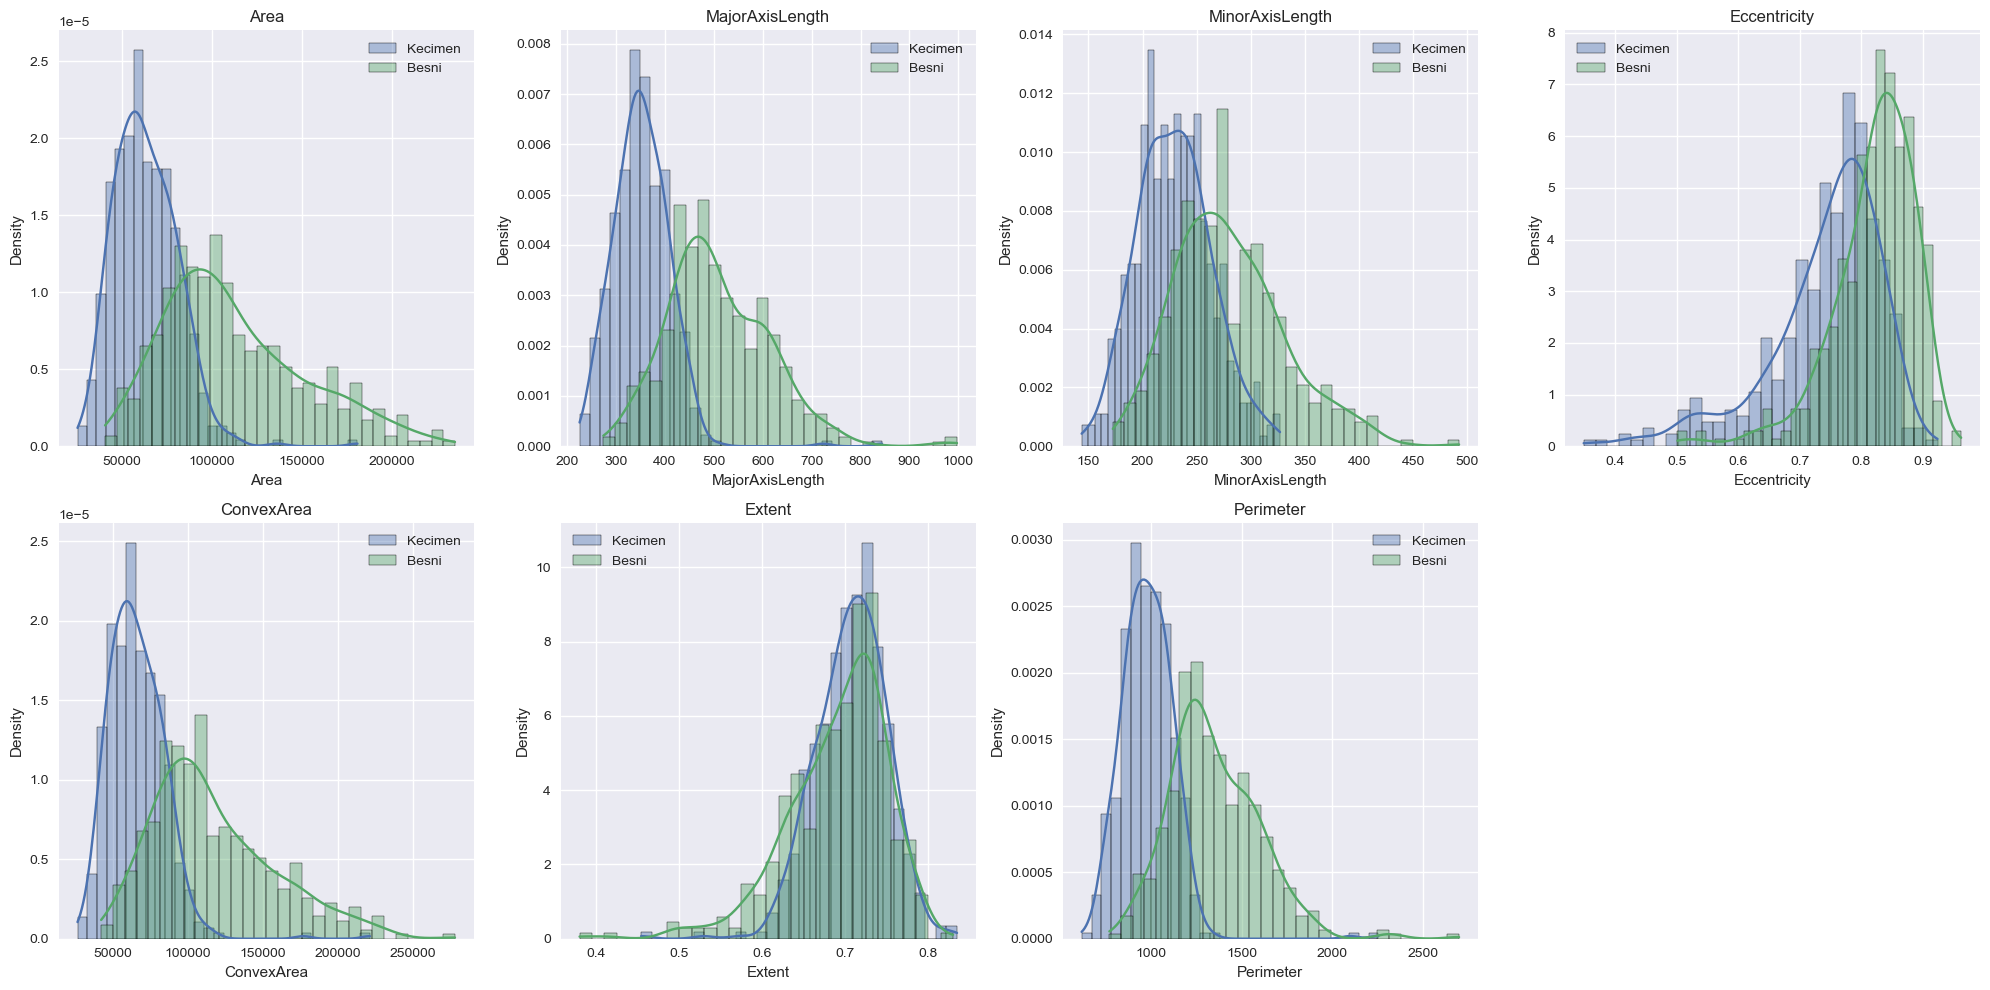

In [394]:
def show_distribution():
    features = ['Area', 'MajorAxisLength', 'MinorAxisLength', 
                'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']

    plt.style.use('seaborn-v0_8')

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()  

    for i, feature in enumerate(features):
        ax = axes[i]
        for cls in data['Class'].unique():
            sns.histplot(
                data[data['Class'] == cls][feature],
                bins=30,
                kde=True,
                stat="density",
                common_norm=False,
                alpha=0.4,
                label=cls,
                ax=ax
            )
        ax.set_title(f'{feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('Density')
        ax.legend()

    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

show_distribution()


In [395]:
from scipy.stats import boxcox

In [396]:
data = pd.read_csv('Raisin_Dataset.csv')

In [397]:
data['Area'] = np.log(1 + data['Area'])
data['Perimeter'] = np.log(1 + data['Perimeter']) 
data['MinorAxisLength'] = np.sqrt(1 + data['MinorAxisLength']) 
data['MajorAxisLength'] = np.cbrt(1 + data['MajorAxisLength']) 

data['Eccentricity'] = np.cbrt(1 + data['Eccentricity']) 
data['ConvexArea'] = np.log(1 + data['ConvexArea']) 


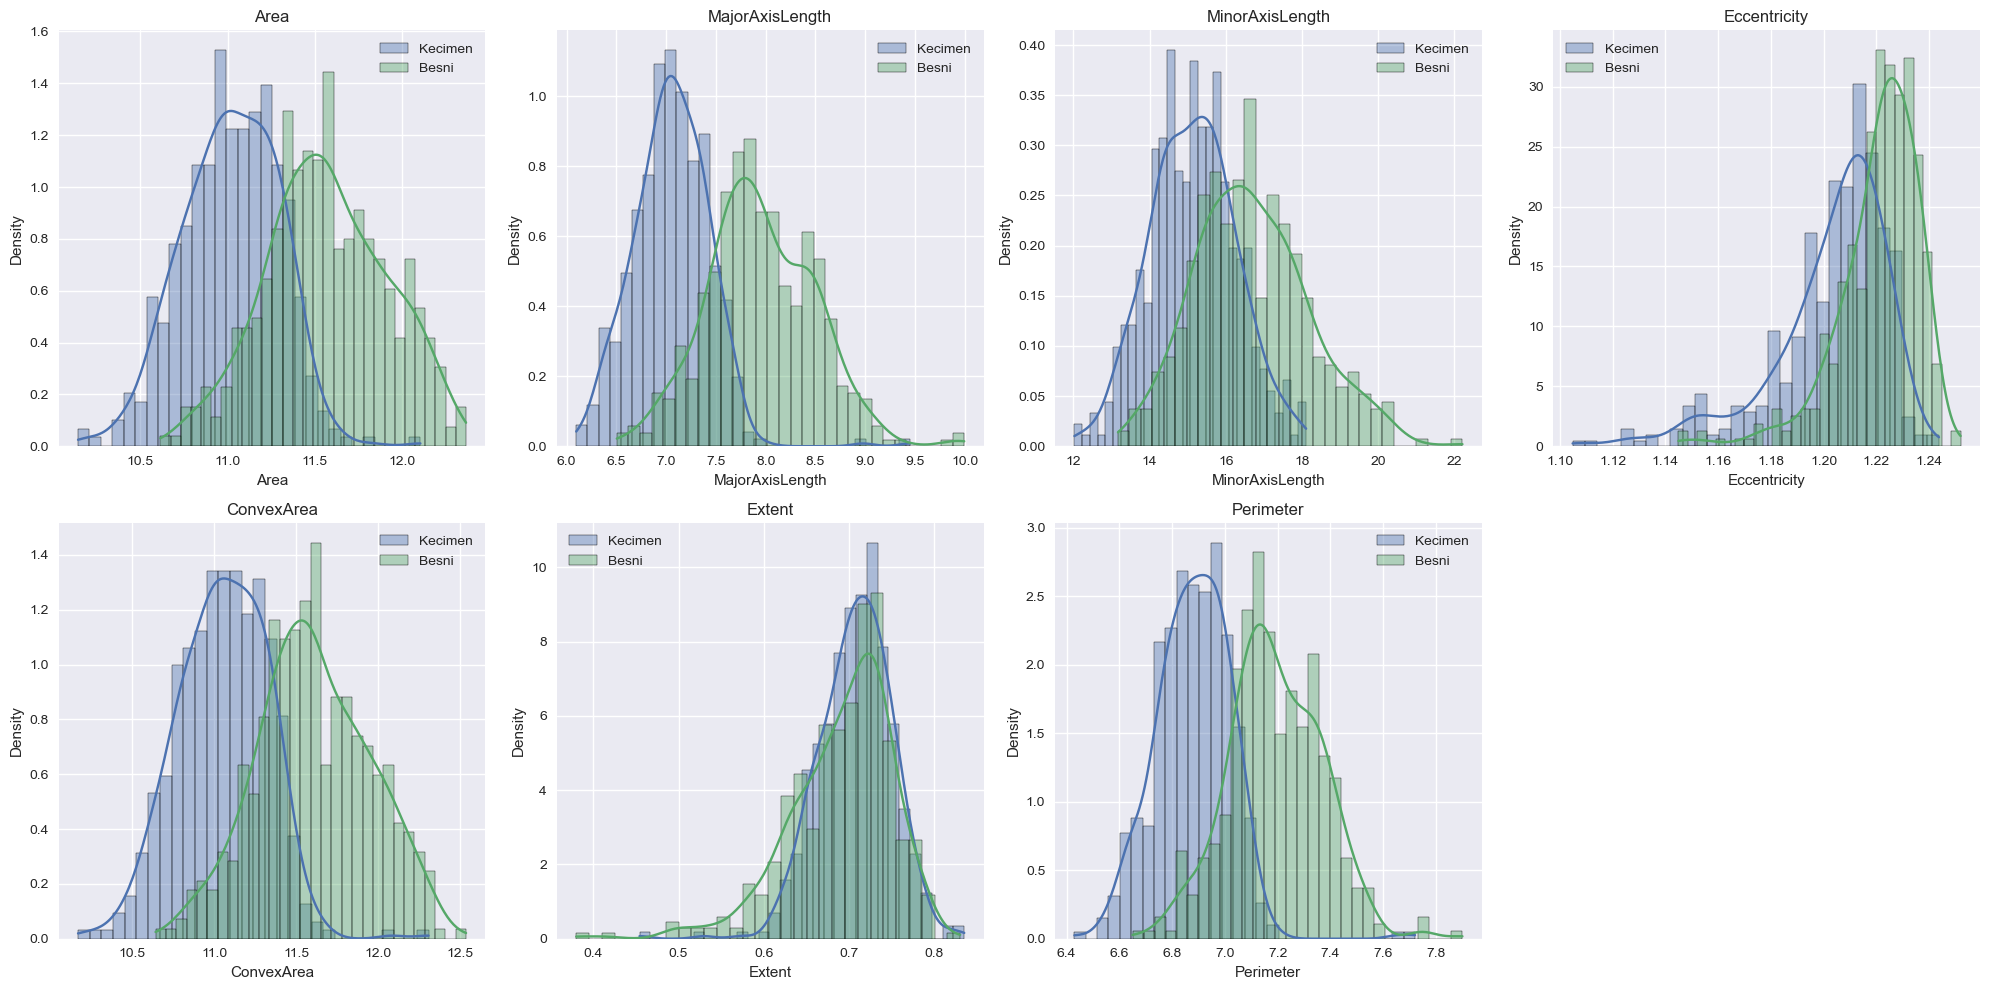

In [398]:
show_distribution()

**2. Модели без калибровки**

Отделив 20% данных в тестовое множество, обучите NB, LDA и QDA. Вычислите accuracy, precision, recall, f1-score на тестовом множестве (можно сделать это с помощью `classification_report`, который печатает сразу много метрик)

Используя встроенные в эти классификаторы методы, вычислите также предсказываемые ими вероятности одного из классов, который мы обзовем положительным. Постройте кривые калибровки. Сделать это можно с помощью функции ниже, которую я украла из склерновского туториала и немного переделала, либо написав свою, более эстетичную версию. Будьте готовы прокомментировать увиденное и объяснить, что это за точки и как определяется, где их рисовать

In [399]:
features = ['Area', 'MajorAxisLength', 'MinorAxisLength','Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
X = data[features]

data['Class'] = data['Class'].map({'Kecimen': 0, 'Besni': 1})
y = data['Class']

In [400]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Naive Bayes': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis()
}

In [401]:
clf_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    
    clf_list.append((model, name, y_prob))


c:\Users\bakru_b9pmn2k\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\bakru_b9pmn2k\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [ ]:
def draw_3_calibrations(clf_list, y_test, n_bins):
    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(3, 3)
    colors = plt.get_cmap("Dark2")

    ax_calibration_curve = fig.add_subplot(gs[:2, :3])
    calibration_displays = {}
    for i, (clf, name, y_prob) in enumerate(clf_list):
        disp = CalibrationDisplay.from_predictions(y_test, y_prob, name=name, n_bins=n_bins, ax=ax_calibration_curve, color=colors(i))
        calibration_displays[name] = disp

    ax_calibration_curve.grid()
    ax_calibration_curve.set_title("Calibration plots")

    grid_positions = [(2, 0), (2, 1), (2, 2)]
    for i, (_, name, _) in enumerate(clf_list):
        row, col = grid_positions[i]
        ax = fig.add_subplot(gs[row, col])

        ax.hist(
            calibration_displays[name].y_prob,
            range=(0, 1),
            bins=10,
            label=name,
            color=colors(i),
        )
        ax.set(title=name, xlabel="Predicted probability", ylabel="Count")

    plt.tight_layout()
    plt.show()

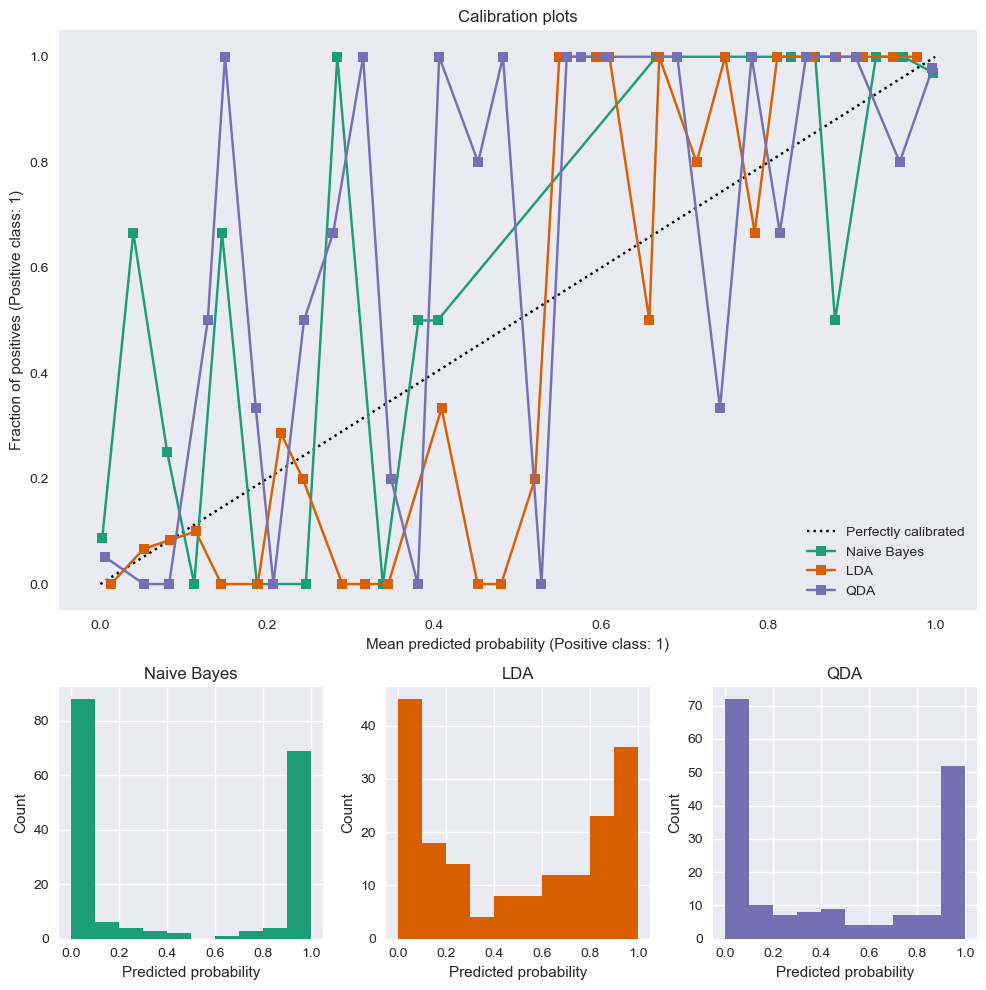

In [403]:
draw_3_calibrations(clf_list, y_test, 30)

**3. Перекалибровка**

Для склерновских моделей перекалибровку вероятностей можно осуществить с помощью встроенного `CalibratedClassifierCV`. Сходите в справку и почитайте, что означает это CV и какие у него последствия. Для каждого базового классификатора обучите откалиброванный с методами `sigmoid` и `isotonic`, установив `ensemble=False`. Снова пересчитайте метрики и отрисуйте кривые калибровки (чтобы не громоздить их 9 штук на один рисунок, можете сделать 3 отдельных, по одному для каждой базовой модели)

In [404]:
from sklearn.calibration import CalibratedClassifierCV

In [405]:
def train(method):
    clf_list = []

    for name, model in models.items():
        calibrated_clf = CalibratedClassifierCV(model, method=method, ensemble=False)
        calibrated_clf.fit(X_train, y_train)
        
        
        y_prob = calibrated_clf.predict_proba(X_test)[:, 1]
        
        clf_list.append((model, name, y_prob))

    return clf_list

c:\Users\bakru_b9pmn2k\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\bakru_b9pmn2k\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\bakru_b9pmn2k\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\bakru_b9pmn2k\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the col

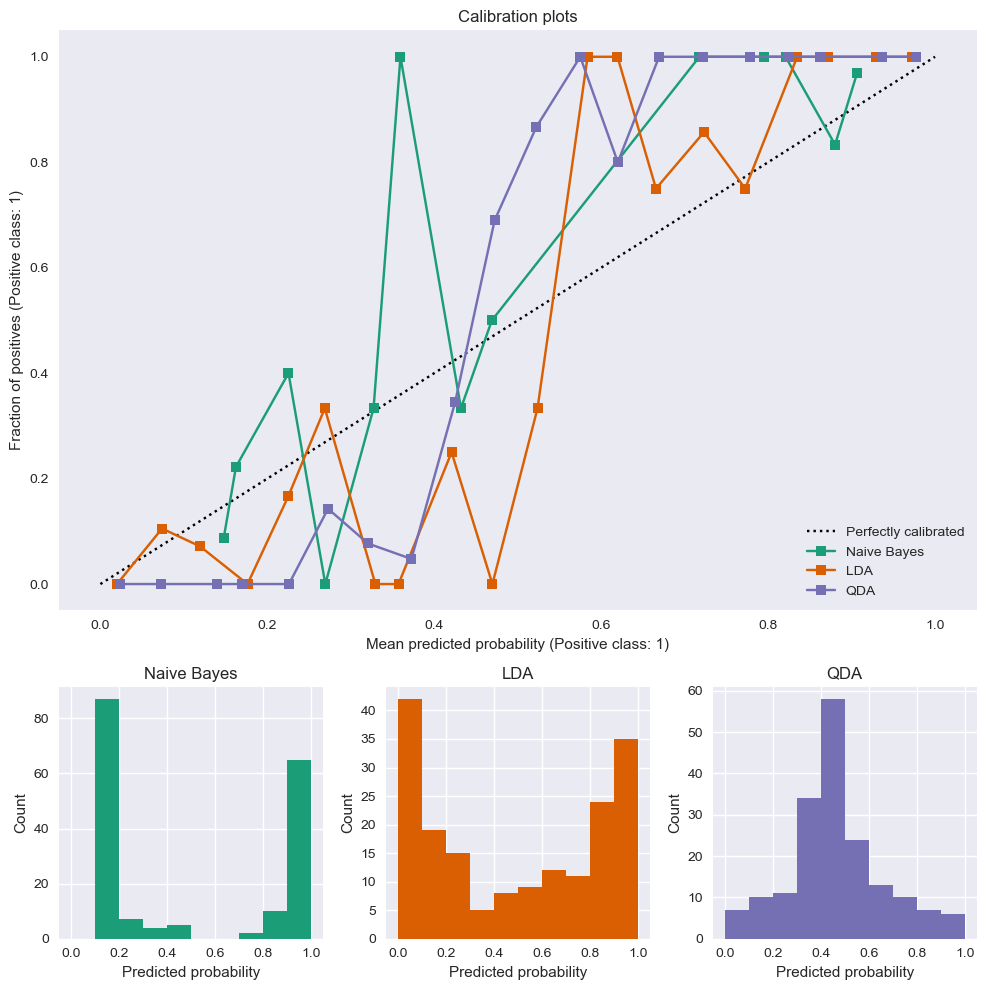

c:\Users\bakru_b9pmn2k\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\bakru_b9pmn2k\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\bakru_b9pmn2k\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\bakru_b9pmn2k\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the col

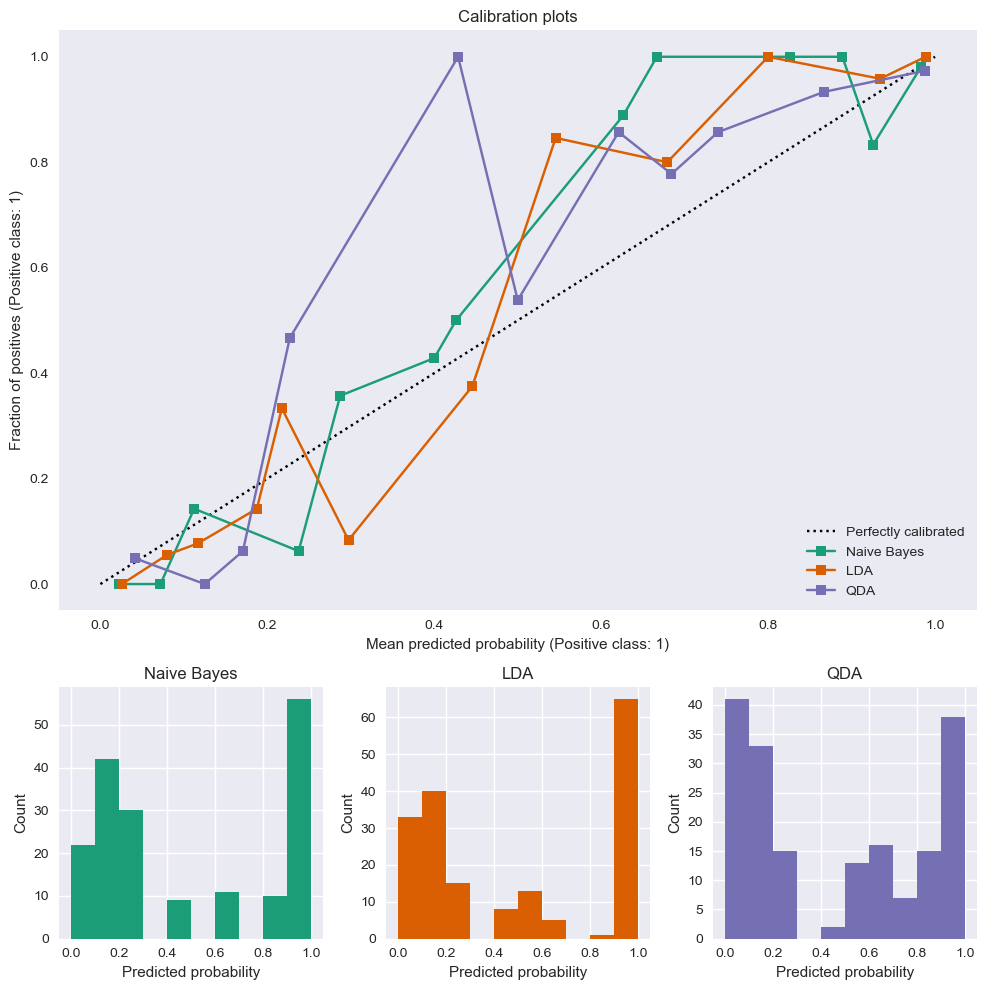

In [406]:
draw_3_calibrations(train('sigmoid'), y_test, 20)
draw_3_calibrations(train('isotonic'), y_test, 20)

Какой метод лучше откалибровал вероятности, если верить картинкам? Как калибровка повлияла на метрики - какому классификатору она была полезна, какому - не очень?

## Часть 2: дисбаланс классов

"На самом деле таска угадывания оттока\мошеннических операций по картам\кто не отдаст долг - это максимально типичная задача которая решается в жизни на каждом шагу половиной компаний у себя - поэтому нам надо это тоже посмотреть чтобы хотя бы примерно прикоснуться к тому с чем есть шанс работать в будущем" - сказал по этому поводу ваш прошлый преподаватель

**1. Предобработка** 

Загрузите данные (источник https://www.kaggle.com/datasets/blastchar/telco-customer-churn). Проверьте на наличие пропусков, определите, какие признаки категориальные, а какие - числовые. Предсказывать мы собираемся Churn

In [407]:
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder

In [408]:
# если вы увидели расширение xls и попробовали прочитать это как эксель, возможно, у вас не получилось
data=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.xls')
data.iloc[0]

customerID                7590-VHVEG
gender                        Female
SeniorCitizen                      0
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                      No
MultipleLines       No phone service
InternetService                  DSL
OnlineSecurity                    No
OnlineBackup                     Yes
DeviceProtection                  No
TechSupport                       No
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 29.85
TotalCharges                   29.85
Churn                             No
Name: 0, dtype: object

In [409]:
data.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [410]:
data = data.dropna()

In [411]:
data = data.drop(['customerID'], axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [412]:
cols_onehot = [
    'gender', 'MultipleLines', 'InternetService',
    'Contract', 'PaymentMethod'
]
data = pd.get_dummies(data, columns=cols_onehot, drop_first=True)

binary_cols = ['Partner', 'Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    data[col] = data[col].map({'Yes':1, 'No':0})

cols_services = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

data = pd.get_dummies(data, columns=cols_services, drop_first=True)

In [413]:
data['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [414]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data = data.dropna(subset=['TotalCharges'])

In [415]:
display(data.info())
data.head(2)

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   int64  
 5   PaperlessBilling                       7032 non-null   int64  
 6   MonthlyCharges                         7032 non-null   float64
 7   TotalCharges                           7032 non-null   float64
 8   Churn                                  7032 non-null   int64  
 9   gender_Male                            7032 non-null   bool   
 10  MultipleLines_No phone service         7032 non-null   bool   
 11  MultipleL

None

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,1,0,1,0,1,29.85,29.85,0,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False


Табличка выше могла ввести нас в заблуждение. Обратите особое внимание на колонку TotalCharges. Осознав, что с ней не так, пересмотрите свои выводы по пропускам и категориальности остальных колонок.

Посмотрите на дисбаланс классов, на расположение пропусков, на другие потенциально связанные с этими пропусками колонки и решите, что вы хотите с ними делать

Сделав все, что хотели, поделите данные на трейн и тест и проверьте, что соотношения классов в них примерно одинаковы

In [416]:
from sklearn.model_selection import train_test_split

In [417]:
# если в процессе вы не избавились от датафрейма, можно сделать это за счет normalize
train, test = train_test_split(data, test_size=0.2, random_state=2)
train['Churn'].value_counts(normalize=True), test['Churn'].value_counts(normalize=True)

(Churn
 0    0.734222
 1    0.265778
 Name: proportion, dtype: float64,
 Churn
 0    0.734186
 1    0.265814
 Name: proportion, dtype: float64)

**2. Логистическая регрессия** 

Предобработайте признаки, чтобы их можно было подавать в регрессию. Будет ли колонка `TotalCharges` избыточной или наоборот, потенциально полезной? Обратите внимание, что при one-hot кодировании вы почти наверняка создаете лишнюю колонку. Если вы не ожидаете, что в тестовых данных появится какая-то неизвестная прежде категория, то значение в одной one-hot колонке линейно выражается через значения в остальных. В `get_dummies` или `OneHotEncoder`'e есть аргумент, позволяющий лишнюю колонку убрать!

Загрузите `LogisticRegression` из sklearn и обучите ее без учета неравенства классов. Вычислите метрики на тестовом и тренировочном наборах: accuracy, precision, recall, f1, roc-auc. Вычислите те же метрики, просто предсказав везде, что "оттока нет", и сделайте вывод о том, какие из них имеют ценность в данной задаче.

Постройте roc- и pr- кривые и объясните, что они такое, почему они так выглядят

- *для построения кривых у sklearn есть готовые функции, правда сами кривые они не рисуют, а только возвращают списки координат, которые надо будет подать в plot, и списки соответствующих границ. Что может быть даже полезно, потому что если бы они отдавали вам только картинки, то вы не могли бы потом понять, какой границе соответствует та замечательная точка графика, где достигается такой хороший баланс между precision и recall*

In [418]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def calculate_metrics_df(y_true, y_pred, y_proba=None, model_name='Model'):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
        
    metrics = {
        'Model/Set': [model_name],
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1-Score': [f1]
    }
    
    return pd.DataFrame(metrics)

In [419]:
y_train = train['Churn']
train = train.drop(columns=['Churn'])

y_test = test['Churn']
test = test.drop(columns=['Churn'])

n_samples = len(y_test)

y_pred_baseline = np.zeros(len(y_test))

y_proba_baseline = np.zeros((len(y_test), 2)) 
y_proba_baseline[:, 0] = 1.0 

In [ ]:
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import precision_recall_curve, roc_curve, accuracy_score 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def train_predict_draw(model, train: pd.DataFrame, y_train: pd.DataFrame, test, y_test, y_pred_baseline, draw_roc):
    model.fit(train, y_train)

    pred_train = model.predict(train)
    pred_test = model.predict(test)

    if hasattr(model, "predict_proba"):
        y_score_train = model.predict_proba(train)[:, 1] 
    else:
        y_sco   re_train = model.decision_function(train)   

    if hasattr(model, "predict_proba"):
        y_score_test = model.predict_proba(test)[:, 1]  
    else:
        y_score_test = model.decision_function(test)    

    
    display(calculate_metrics_df(pred_train, y_train, y_score_train, 'LR_train'))
    display(calculate_metrics_df(pred_test, y_test, y_score_test, 'LR_test'))
    display(calculate_metrics_df(y_pred_baseline, y_test, None, 'baseline'))

    precision, recall, thresholds = precision_recall_curve(y_test, y_score_test)
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_score_test)

    # 1. Precision-Recall Curve
    plt.figure(figsize=(5, 3))
    plt.plot(recall, precision, label='Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. ROC Curve
    if draw_roc:
        plt.figure(figsize=(10, 6))
        plt.plot(fpr, tpr, label='ROC Curve') 
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray',)
        plt.xlabel('False Positive Rate (FPR)')
        plt.ylabel('True Positive Rate (TPR / Recall)')
        plt.title('ROC')
        plt.legend()
        plt.grid(True)
        plt.show()

,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_train,0.805156,0.553177,0.658964,0.601455


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_test,0.805259,0.580214,0.649701,0.612994


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,baseline,0.734186,0.0,0.0,0.0


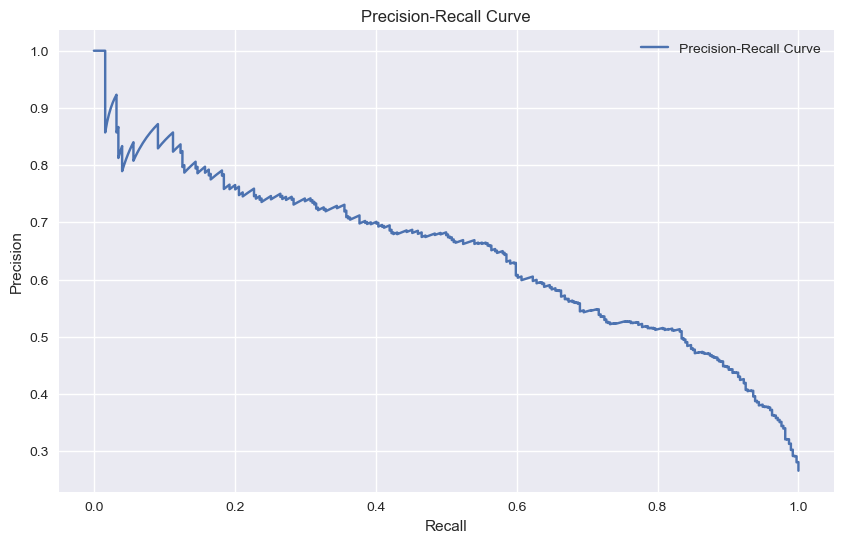

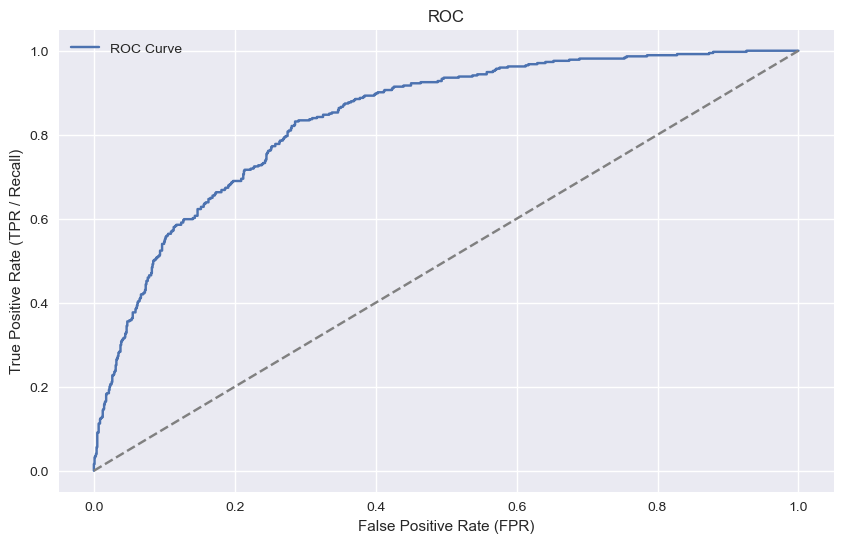

In [421]:
model = LogisticRegression(max_iter=10000, penalty='l2')
train_predict_draw(model, train, y_train, y_pred_baseline)


**3. Дисбаланс классов** 

Когда мы выводили формулы для логистической регрессии, мы использовали предоположение о равенстве классов ($P(y=0)=P(y=1)$). Допустим, на самом деле соотношение между классами $\frac{P(y=0)}{P(y=1)}=\alpha$, но мы это проигнорировали и вычислили $P(y=1|X)$ и log odds (это $z=\log \frac{P(y=1|X)}{P(y=0|X)}$, и оно говорит нам о том, где проходит разделяющая плоскость) по старой формуле. 

1) Выведите, в каком соотношении находятся эти значения вероятностей с "честными". Предложите, что изменить в обучении или инференсе, чтобы учесть дисбаланс классов и снова считать правильные вероятности. Запишите!

$real_{odds} = model_{odds} \cdot \frac{1}{\alpha}$

$\ln{real_{odds}} = \ln{model_{odds}} + \ln{\frac{1}{\alpha}}$

формула для «честной» вероятности:

$P_{real}(y=1∣X)= \frac{1}{1 + e^{-(z_{model}-\ln{a})}}$

2) Спуститесь в глубину архивов исходного кода sklearn для логистической регрессии (попасть туда можно, нажав \[source\] на страничке справки). Там найдите древние свитки, на которых записано, как дисбаланс классов обрабатывается в `LogisticRegression`. Перепишите эти знания предков в ноутбук и попробуйте объяснить, почему было сделано именно так.

```
# If class_weights is a dict (provided by the user), the weights
# are assigned to the original labels. If it is "balanced", then
# the class_weights are assigned after masking the labels with a OvR.
le = LabelEncoder()
if isinstance(class_weight, dict) or (
    multi_class == "multinomial" and class_weight is not None
):
    class_weight_ = compute_class_weight(
        class_weight, classes=classes, y=y, sample_weight=sample_weight
    )
    sample_weight *= class_weight_[le.fit_transform(y)]

# for compute_class_weight (OvR)
if multi_class == "ovr":
    ...
    if class_weight == "balanced":
        class_weight_ = compute_class_weight(
            class_weight,
            classes=mask_classes,
            y=y_bin,
            sample_weight=sample_weight,
        )
        sample_weight *= class_weight_[le.fit_transform(y_bin)]
```


3) Выбравшись из архивов, переобучите регрессию уже с учетом дисбаланса классов и пересчитайте все те же метрики. Посмотрите на precision-recall кривую, оцените, следует ли вам сдвинуть threshold с 0.5 куда-то еще. На основании чего вы можете сделать такой вывод?

**Дальше будет задание где нам нужны все наши модели одновременно, так что не удаляйте их из памяти пока!**

- *Для перебора параметров вообще можно использовать `GridSearchCV` или `RandomizedSearchCV`. Однако он требует выбрать некоторую метрику для сравнения*
- *заметьте, что никто не запрещает вам поставить в `class_weight` какие угодно коэффициенты дисбаланса. Как знать, может, нужная вам метрика станет лучше, если вы соврете о степени дисбаланса?*
- *`f1_score` - выбор желающих усидеть на двух стульях. Но что если мы хотим усидеть на одном стуле немного больше, чем на втором: мы как бы подозреваем, что, например, recall, важнее, но все же не хотим упускать из виду precision? Существует `fbeta_score` - взвешенная версия*

,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_train,0.752178,0.808027,0.521814,0.634121


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_test,0.744847,0.799465,0.512864,0.624869


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,baseline,0.734186,0.0,0.0,0.0


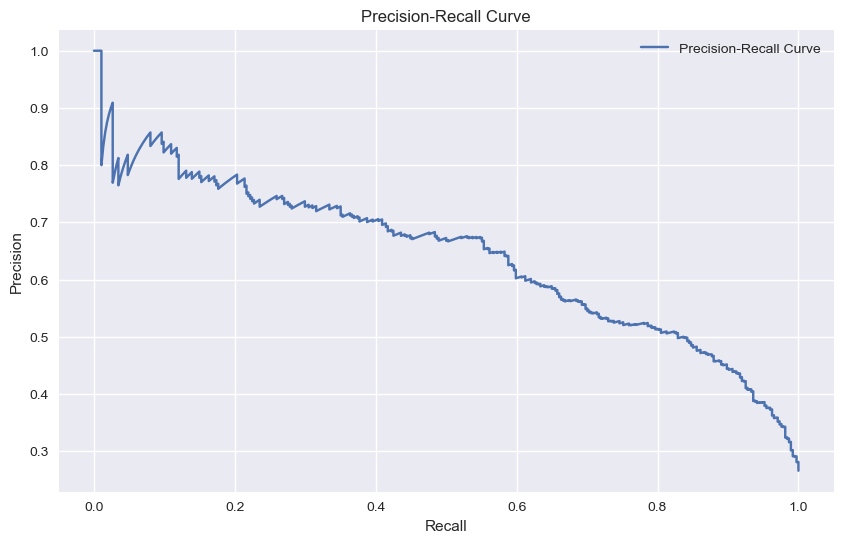

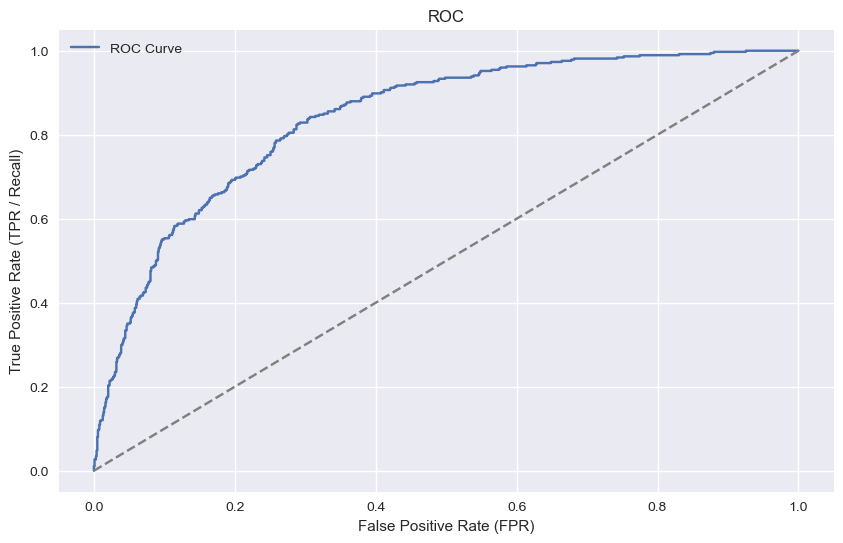

In [422]:
model_balanced = LogisticRegression(class_weight='balanced', max_iter=10000, penalty='l2')
train_predict_draw(model_balanced, train, y_train, y_pred_baseline)

In [71]:
# как-то вот так это может работать, если вы хотите еспользовать ее в переборе параметров
fb = make_scorer(fbeta_score, beta=3)
grid = GridSearchCV(base_classifier, param_grid={...}, scoring=fb, cv=3)

NameError: name 'base_classifier' is not defined

**4. Обыкновенная регрессия**

Попробуйте решить задачу с помощью `RidgeClassifier` и сравните метрики с логистической регрессией. Может, не так плоха линейная регрессия на друх классах?

Нам в этой лабе понадобятся вероятности, а у `RidgeClassifier` их нет, разве что какие-то confidence scores. Чтобы не посылать вас обратно копаться в исходном коде, просто скажем, что наши вероятности будут считаться взятием сигмоиды от того, что вернула `decision_function`

In [292]:
from sklearn.linear_model import RidgeClassifier

,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_train,0.801067,0.516388,0.660959,0.579797


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_test,0.803127,0.550802,0.653968,0.597968


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,baseline,0.734186,0.0,0.0,0.0


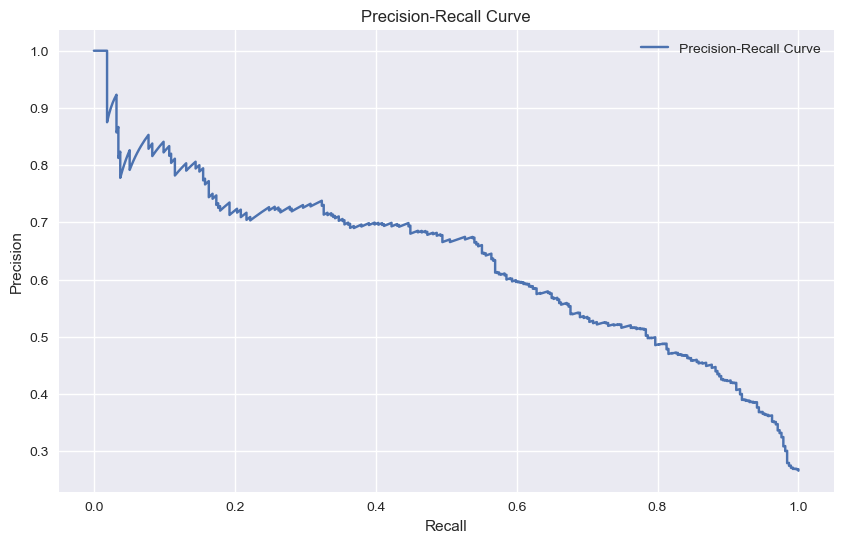

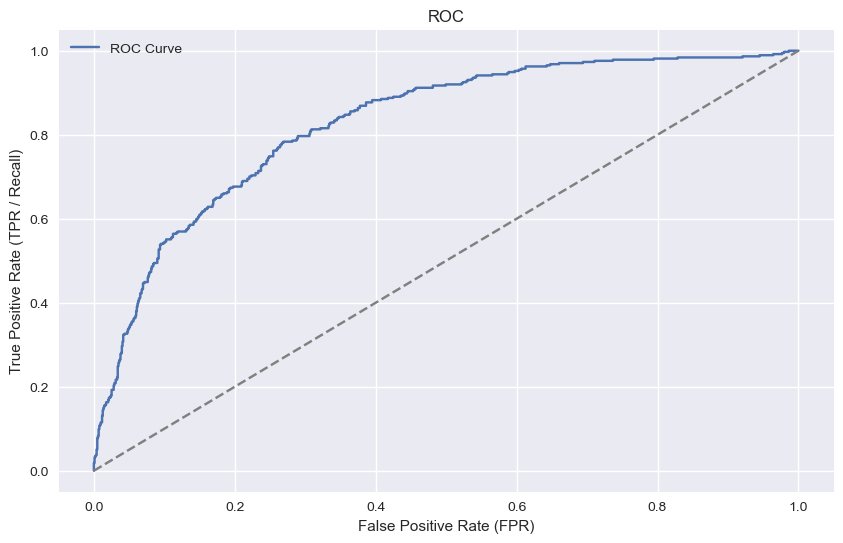

In [ ]:
model_ridge_classifier = RidgeClassifier(max_iter=10000, alpha=0.1)
train_predict_draw(model_ridge_classifier, train, y_train, y_pred_baseline)

**5. Наивный Байес** 

Хотелось бы опробовать наивный байесовский классификатор на этой задаче, раз уж для L/QDA она не очень подходит в силу кучи категорий, но вот беда: наши признаки и категориальные, и числовые. Казалось бы, в чем проблема, но похоже в sklearn до сих пор нет версии байеса, которая бы умела с таким работать. Ваши варианты:

- подумать, как можно собрать математически эквивалентную версию из `GaussianNB` и `CategoricalNB`
- написать свой NB с нуля
- установить вот эту имплементацию https://github.com/remykarem/mixed-naive-bayes/tree/master

Выбирая вариант, учтите, что дальше нам от этого классификатора потребуются не просто ответы, а вероятности, или их подобие. У sklearn классификаторы обычно имеют метод `predict_proba`. В mixed-naive-bayes он какой-то тоже есть.

Прежде чем приступать к обучению классификатора, можно проверить кое-что еще. Наши численные признаки. Если вы не выбрали писать свой собственный классификатор, то заметьте, что готовый ожидает, что численные признаки нормально распределены. Но так ли это? Что вы можете сделать? Стоит ли оно того?

*логистическая регрессия с сигмоидой конечно тоже была заинтересована в нормальном распределении, но нам все равно пришлось бы скормить ей кучу категориальных фичей, так что...*

Обучите байесовский классификатор, посчитайте метрики

- *Для кодирования категориальных признаков для байеса лучше подойдет не one-hot, а `OrdinalEncoder`. Сравните его также с `LabelEncoder`: в чем разница?*

In [306]:
!pip install mixed-naive-bayes

In [311]:
from mixed_naive_bayes import MixedNB
from sklearn.preprocessing import PowerTransformer, OrdinalEncoder

In [434]:
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

X_train_num = train[numeric_cols]
X_test_num = test[numeric_cols]

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_cat = oe.fit_transform(train[categorical_cols])
X_test_cat = oe.transform(test[categorical_cols])

for i in range(X_train_cat.shape[1]):
    max_val = np.max(X_train_cat[:, i])
    X_train_cat[X_train_cat[:, i] == -1, i] = max_val + 1
    X_test_cat[X_test_cat[:, i] == -1, i] = max_val + 1

X_train_nb = np.hstack([X_train_num, X_train_cat])
X_test_nb = np.hstack([X_test_num, X_test_cat])

cat_indices = list(range(len(numeric_cols), X_train_nb.shape[1]))

In [435]:
class ConvincingMixedNB(MixedNB):
    def __init__(self, categorical_features=None, max_categories=None,
                 alpha=0.5, priors=None, var_smoothing=1e-9):
        super().__init__(categorical_features=categorical_features, 
                         max_categories=max_categories, 
                         alpha=alpha, 
                         priors=priors, 
                         var_smoothing=var_smoothing)
        self.classes_ = np.array([0, 1])
        self._estimator_type = 'classifier'

model_nb = ConvincingMixedNB(categorical_features=cat_indices)

model_nb.fit(X_train_nb, y_train)

y_proba_nb_test = model_nb.predict_proba(X_test_nb)[:, 1]
y_pred_nb_test = model_nb.predict(X_test_nb)

display(calculate_metrics_df(y_test, y_pred_nb_test, y_proba_nb_test, 'MixedNB'))

,Model/Set,Accuracy,Precision,Recall,F1-Score
0,MixedNB,0.722814,0.486667,0.780749,0.599589


**6. Калибровка вероятностей**

1) Для наших классификаторов (логистическая регрессия, линейная регрессия, байесовский) постройте кривые калибровки вероятностей и прокомментируйте. 

> Как выглядят кривые калибровки для очень неуверенного классификатора? Для очень уверенного, но дающего неправильные ответы?

2. Попробуйте поправить вероятности. Для этого вообще существует `CalibratedClassifierCV`. Ниже приведен пример использования - разберитесь, что это за аргументы.

> Каждый из трех классификаторов засуньте вместе с тренировочным множеством в калибровщик. Попробуйте как `sigmoid`, так и `isotonic`. Постройте scatter графики старых и новых вероятностей, опишите, что с ними стало после калибровки. Отрисуйе новые кривые калибровки вместе со старыми (опять же, можно сделать три графика, отдельный для каждого классификатора).

In [ ]:
base_lr = LogisticRegression(...)# тут внутрь можно прописать ваши параметры, которые вы хотите зафиксировать
sigmoid_lr = CalibratedClassifierCV(base_lr, cv=4, method='sigmoid', ensemble=False)

Если вы написали своего наивного байеса, я за него не отвечаю, а вот если воспользовались готовым, то сейчас столкнетесь с проблемой: он не совсем совместим с этой калибровочной оболочкой. В частности, оболочка не верит, что это вообще классификатор и это вызывает проблемы в процессе. Возможно, вы придумаете какое-то более элегантное решение. Если вы тоже не особо программист, то, полистав исходный код, могу предложить вам следующий костыль: выдать ему фальшивое удостоверение классификатора и парочку классов для нашего конкретного случая.

In [441]:
class ConvincingMixedNB(MixedNB):
    def __init__(self, categorical_features=None, max_categories=None,
                 alpha=0.5, priors=None, var_smoothing=1e-9):
        MixedNB.__init__(self, categorical_features, max_categories, alpha, priors, var_smoothing)
        self.classes_ = np.array([0,1])
        self._estimator_type = 'classifier'
    def fit(self, X, y):
        # ИСПРАВЛЕНИЕ 
        if isinstance(self.categorical_features, np.ndarray):
            self.categorical_features = self.categorical_features.tolist()

        return super().fit(X, y)

Пересчитайте метрики, сравните со старыми. Также перерисуйте precision-recall кривые и сравните со старыми. Увиденное объясните.

In [442]:
lr_base = LogisticRegression(max_iter=10000, random_state=42)
ridge_base = RidgeClassifier(max_iter=10000)
nb_base = ConvincingMixedNB(categorical_features=cat_indices)

models = {
    'LogReg': (lr_base, train, test), 
    'Ridge': (ridge_base, train, test),
    'MixedNB': (nb_base, X_train_nb, X_test_nb) 
}

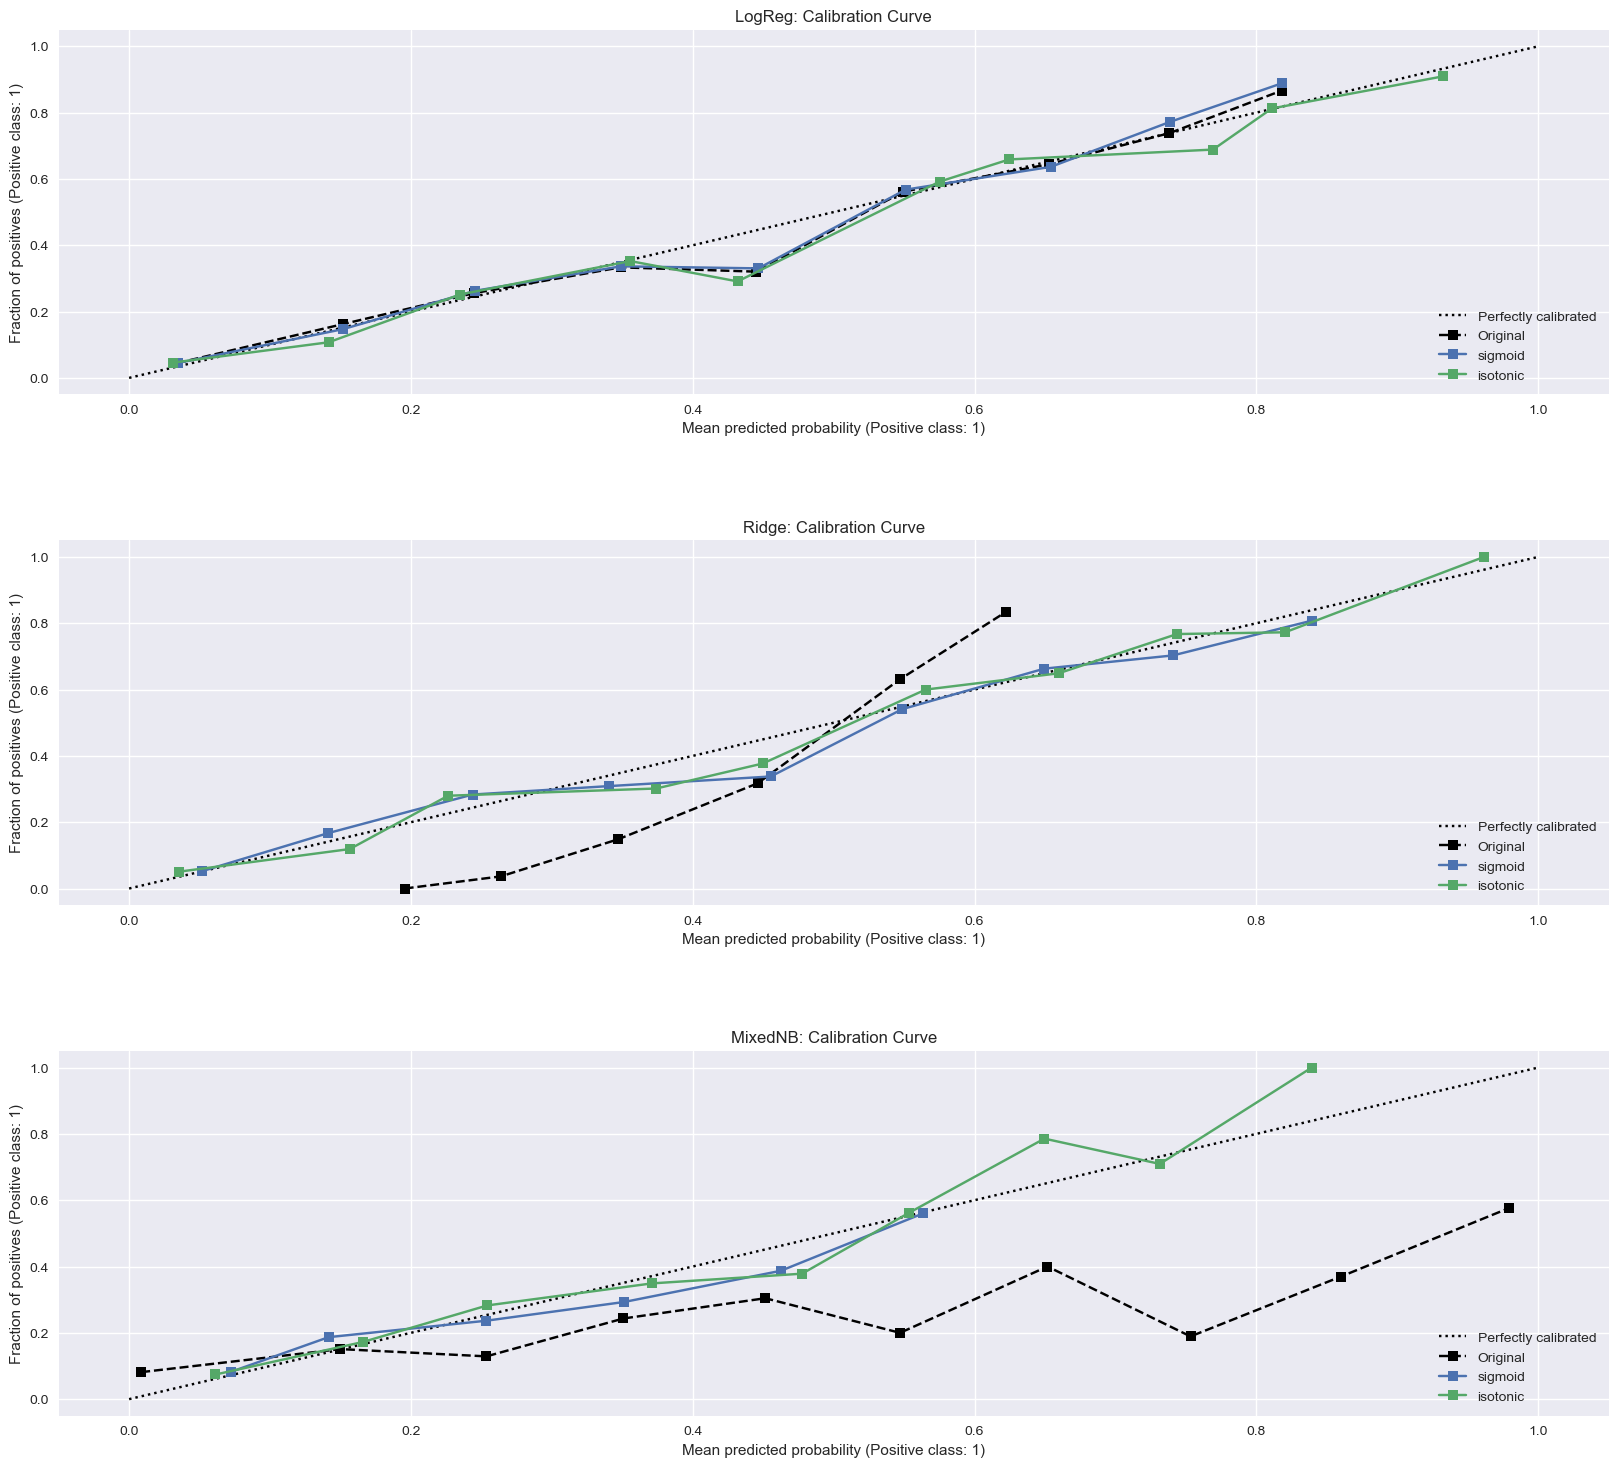

,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LogReg_sigmoid,0.804549,0.651376,0.569519,0.607703
1,LogReg_isotonic,0.806681,0.662420,0.556150,0.604651
2,Ridge_sigmoid,0.801706,0.649842,0.550802,0.596237
3,Ridge_isotonic,0.801706,0.680608,0.478610,0.562009
4,MixedNB_sigmoid,0.769723,0.560386,0.620321,0.588832
5,MixedNB_isotonic,0.791756,0.636364,0.505348,0.563338


In [443]:
fig, axes = plt.subplots(3, 1, figsize=(20, 18))
plt.subplots_adjust(hspace=0.4)

methods = ['sigmoid', 'isotonic']

results_table = []

for i, (name, (model, X_tr, X_te)) in enumerate(models.items()):
    model.fit(X_tr, y_train)
    
    if hasattr(model, "predict_proba"):
        prob_orig = model.predict_proba(X_te)[:, 1]
    else:
        from scipy.special import expit
        prob_orig = expit(model.decision_function(X_te))

    ax_calib = axes[i]
    CalibrationDisplay.from_predictions(y_test, prob_orig, n_bins=10, name='Original', ax=ax_calib, color='black', linestyle='--')
    
    calibrated_probs = {}

    for method in methods:
        calibrated_model = CalibratedClassifierCV(model, cv=3, method=method, ensemble=False) 
        calibrated_model.fit(X_tr, y_train)
    
        prob_new = calibrated_model.predict_proba(X_te)[:, 1]
        pred_new = calibrated_model.predict(X_te)
        calibrated_probs[method] = prob_new
        
        CalibrationDisplay.from_predictions(y_test, prob_new, n_bins=10, name=f'{method}', ax=ax_calib)
         
        res_df = calculate_metrics_df(y_test, pred_new, prob_new, f'{name}_{method}')
        results_table.append(res_df)

    ax_calib.set_title(f'{name}: Calibration Curve')
    ax_calib.grid(True)

plt.show()

final_metrics = pd.concat(results_table, ignore_index=True)
display(final_metrics)

,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_train,0.805156,0.553177,0.658964,0.601455


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_test,0.805259,0.580214,0.649701,0.612994


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,baseline,0.734186,0.0,0.0,0.0


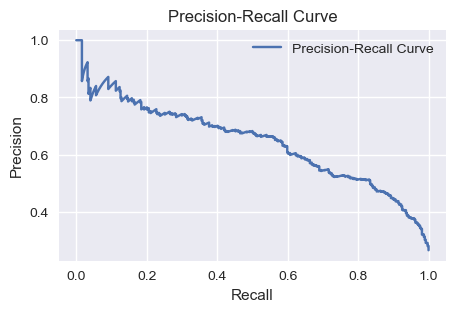

,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_train,0.805333,0.548495,0.66129,0.599634


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_test,0.804549,0.569519,0.651376,0.607703


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,baseline,0.734186,0.0,0.0,0.0


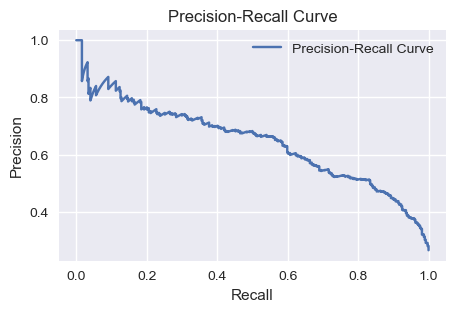

,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_train,0.801422,0.517057,0.661815,0.580548


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_test,0.803127,0.550802,0.653968,0.597968


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,baseline,0.734186,0.0,0.0,0.0


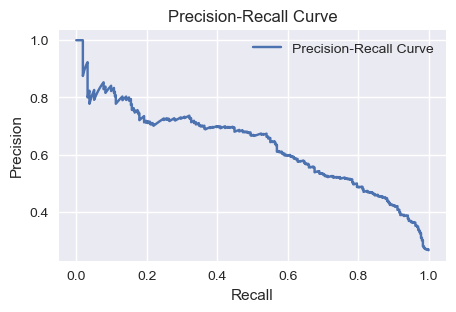

,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_train,0.799822,0.520401,0.655434,0.580164


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_test,0.801706,0.550802,0.649842,0.596237


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,baseline,0.734186,0.0,0.0,0.0


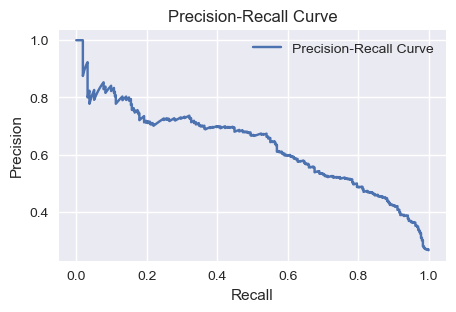

,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_train,0.733867,0.802007,0.499583,0.615661


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_test,0.722814,0.780749,0.486667,0.599589


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,baseline,0.734186,0.0,0.0,0.0


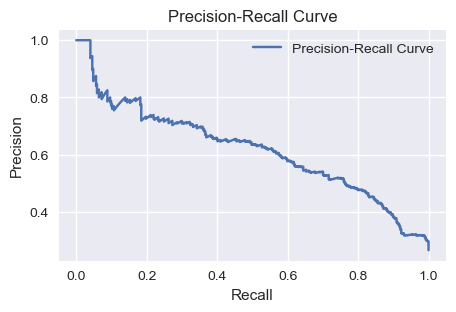

,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_train,0.785422,0.644147,0.587912,0.614746


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,LR_test,0.769723,0.620321,0.560386,0.588832


,Model/Set,Accuracy,Precision,Recall,F1-Score
0,baseline,0.734186,0.0,0.0,0.0


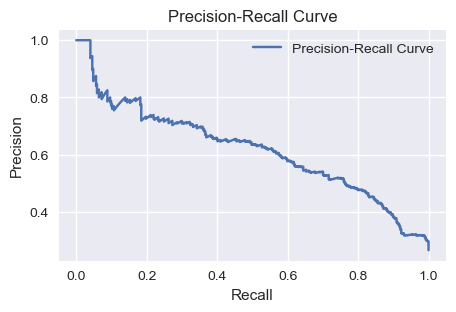

In [453]:
for name, (model, X_tr, X_te) in models.items():
    train_predict_draw(model, X_tr, y_train, X_te, y_test, y_pred_baseline, False)
    
    calibrated_model = CalibratedClassifierCV(model, cv=3, method='sigmoid', ensemble=False)
    train_predict_draw(calibrated_model, X_tr, y_train, X_te, y_test, y_pred_baseline, False)